# Q7.
```{admonition}
:class: note
Create a plot displaying the test error resulting from random forests on the `Boston` data set for a more comprehensive range of values for `max_features` and `n_estimators`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [3]:
import seaborn as sns

In [ ]:
boston = pd.read_csv('../../../ALL CSV FILES - 2nd Edition/Boston.csv',index_col=0)

In [5]:
boston.sample(3)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
218,0.07013,0.0,13.89,0,0.550,6.642,85.1,3.4211,5,276,16.4,9.69,28.7
339,0.03306,0.0,5.19,0,0.515,6.059,37.3,4.8122,5,224,20.2,8.51,20.6
456,4.75237,0.0,18.10,0,0.713,6.525,86.5,2.4358,24,666,20.2,18.13,14.1


In [6]:
boston_X, boston_y = boston.drop(columns='medv'), boston['medv']
X_train, X_test, y_train, y_test = train_test_split(boston_X,boston_y,random_state=1728)
feature_count = X_train.shape[1]

In [7]:
test_errors = defaultdict(list)
max_estimators = 300
for i in range(1,feature_count+1):
    for j in range(1,max_estimators+1,5):
        rfr = RandomForestRegressor(n_estimators=j,max_features=i,random_state=1728,n_jobs=-1).fit(X_train,y_train)
        test_errors[i].append(mean_squared_error(y_test,rfr.predict(X_test)))

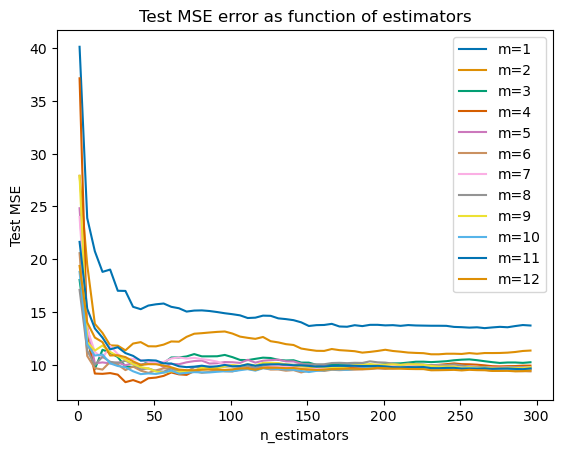

In [8]:
xs = np.arange(1,max_estimators+1,5)
palette=sns.color_palette('colorblind',feature_count)
for i in range(feature_count):
    sns.lineplot(x=xs,y=test_errors[i+1],color=palette[i],label=f'm={i+1}')
plt.legend()
plt.title('Test MSE error as function of estimators')
plt.xlabel('n_estimators')
plt.ylabel('Test MSE')
plt.show()